In [1]:
# Steel model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from scipy.optimize import OptimizeWarning
warnings.simplefilter('ignore', OptimizeWarning)

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (all_regions_list_class, 
                                          models_output_dict)

In [2]:
# Steel
steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                       image_mat_available = True, start_year = 1971, 
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)


high = ['class_ 16', 'class_ 19', 'class_ 20', ]

medium = ['class_ 1', 'class_ 23'] 

low = ['class_ 2', 'class_ 11' , 'class_ 24']

# trajectory not to forseen, will be fitted with global regression
low_gdp = ['class_ 3', 'class_ 4', 'class_ 5', 'class_ 6', 
           'class_ 7', 'class_ 8', 'class_ 9',  'class_ 10',
           'class_ 15', 'class_ 17', 'class_ 18', 'class_ 21', 
           'class_ 22', 'class_ 25', 'class_ 26']

# what is in rset will not be fitted because of outliers - will follow global projections       
rest = all_regions_list_class[:-1]

rest = [r for r in rest if r not in (high+low+medium)]
print(rest)

# for these models a regression will be made
# all reginos that are not in the high, medium, low will be fitted with the global regression
steel_grouping = {'all' : all_regions_list_class[:-1],
                  'high': high,
                  'medium': medium,
                  'low': low,
                  }

#steel_grouping = {'all' : all_regions_list_class[:-1]}
steel.data_grouped_regions(regions_grouping = steel_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
steel.sum_IMAGE_drivers_regions(regions_dict=None)

steel.match_MAT_data_to_regions_year(match_external_regions=False)
steel.calculate_historic_other_fraction()

['class_ 3', 'class_ 4', 'class_ 5', 'class_ 6', 'class_ 7', 'class_ 8', 'class_ 9', 'class_ 10', 'class_ 12', 'class_ 13', 'class_ 14', 'class_ 15', 'class_ 17', 'class_ 18', 'class_ 21', 'class_ 22', 'class_ 25', 'class_ 26']


In [3]:
# Share of IAMGE MAT data to total consumption
share_mat_total = (steel.image_mat_data/steel.historic_consumption_data*100).mean()

In [4]:
# deal with regions where there are negative values because consumption was lower than mat projections
steel.historic_other_fraction_consumption[['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']]

# too many negative: class 4, 8, 9, 22, 25, 26
# assumption: IMAGE MATERIALS is overestimating, 
# real consumption numbers are true &  
# TODO: MATERIALS calculations should be scaled down accordingly 

neg_classes = ['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']
steel.historic_other_fraction_consumption[neg_classes] = steel.historic_consumption_data[neg_classes]

# deal with single negative numbers by removing them from dataset
steel.historic_other_fraction_consumption[steel.historic_other_fraction_consumption < 0] = np.nan


<Axes: >

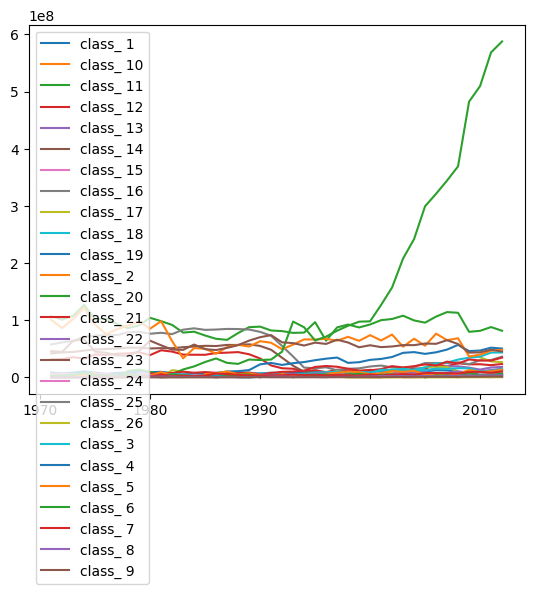

In [5]:
# Plot
steel.historic_other_fraction_consumption.plot()

In [6]:

# Fit models 
steel.calculate_regressors(steel.historic_other_fraction_consumption)

# enforce that for all groups gompertz model is selected as best fit
steel.fit_models(best_rmse_models={'all' : 'gompertz model',
                                   'high': 'gompertz model',
                                   'medium': 'gompertz model',
                                   'low': 'gompertz model'})


# project based on best model
steel.project_on_total(all_regions_list_class[:-1])

all
high
medium
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.
low


C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:281: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * np.exp(-c * X))


steel.region_model_match

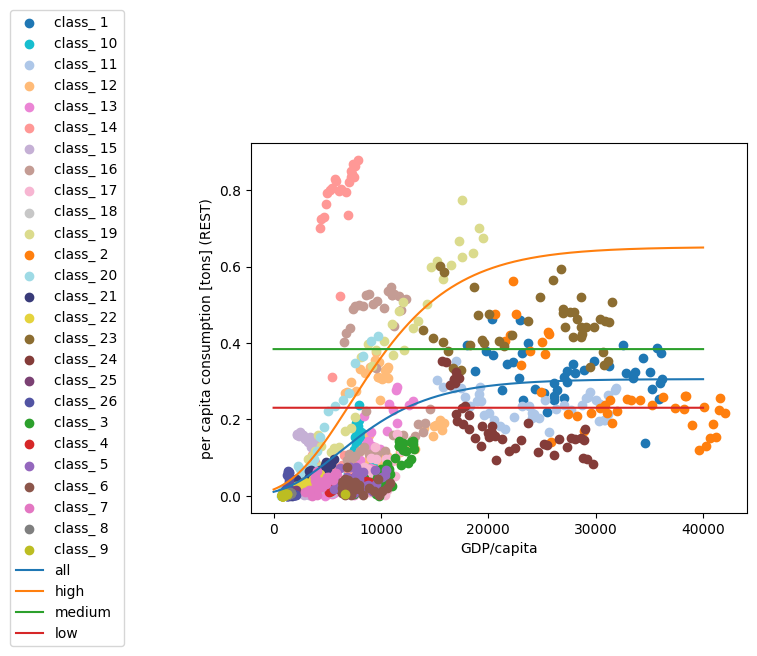

In [7]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', "#EB85D5", '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', "#E4D33D", '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in steel.cons_capita.columns:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in steel_grouping.keys():
    model = steel.model_groups[grouping][models_output_dict[steel.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1)),
            label = grouping)

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")



ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))


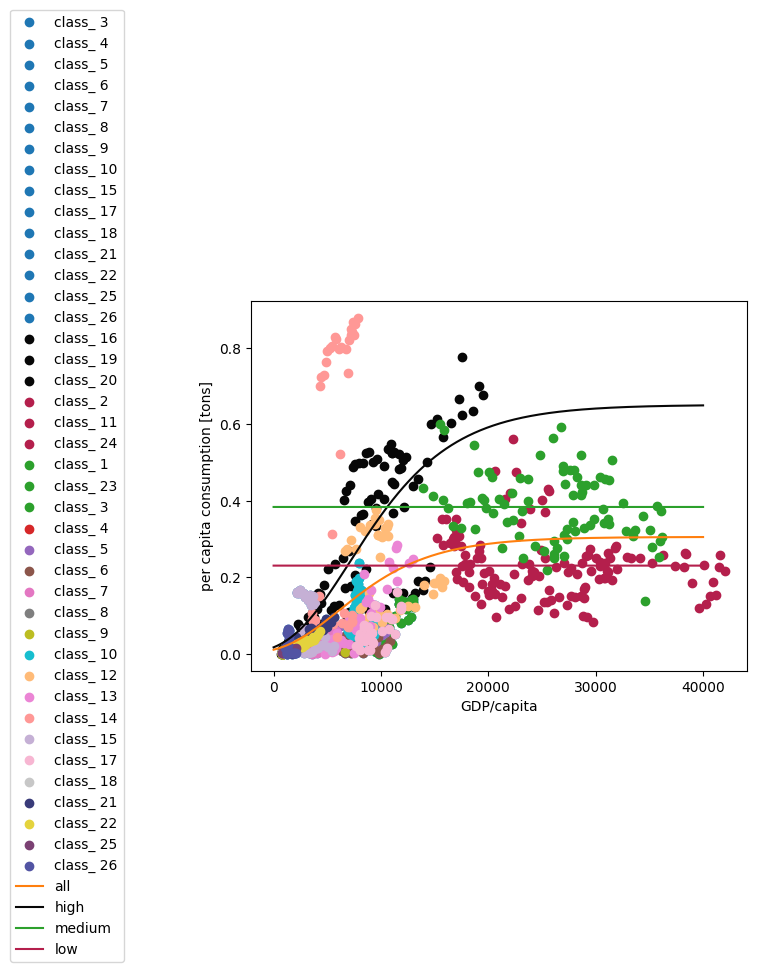

In [8]:
# Grouping of regions for fitting

color_low_gdp = '#1f77b4'
color_low = "#b41f4c"
color_high = "#070707"
color_medium = '#2ca02c'

color_dict_fits = {
    'low_gdp': color_low_gdp,
    'low': color_low,
    'medium': color_medium,
    'high': color_high,
    'all': '#ff7f0e',  # Color for all regions

}


fig, ax = plt.subplots()             # Create a figure containing a single Axes.
for region in low_gdp:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_low_gdp)
    
for region in high:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_high)

for region in low:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_low)

for region in medium:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_medium)

for region in rest:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in steel_grouping.keys():
    model = steel.model_groups[grouping][models_output_dict[steel.best_rmse_models[grouping]]]
    print(model)
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])


ax.set_ylabel("per capita consumption [tons]")
ax.set_xlabel("GDP/capita")
plt.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))

In [9]:

def smooth_out_interpolation_all( nr_years_interpolate: int, start_year = 2012):
    for region in steel.projection_per_region_total.columns:
        start_interpolate = steel.historic_other_fraction_consumption[region].loc[start_year:2012]
        end_interpolate = steel.projection_per_region_total[region].loc[start_year+nr_years_interpolate:start_year+nr_years_interpolate]

        # interpolate between the two points
        interpolated = pd.Series(np.linspace(start_interpolate.values[0], end_interpolate.values[0], nr_years_interpolate+1), 
                                index = steel.projection_per_region_total[region].loc[start_year:start_year+nr_years_interpolate].index)

        # replace the values in the projection with the interpolated values
        steel.projection_per_region_total[region].loc[start_year:start_year+nr_years_interpolate] = interpolated 

smooth_out_interpolation_all(15, 2012)

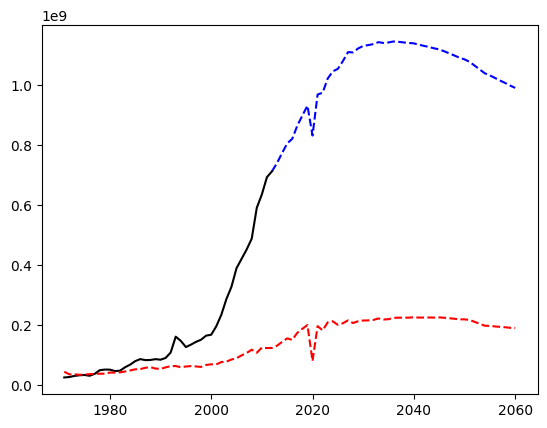

In [10]:
def plot_overview_figure_total_consumption_region(region: str):

    fig, ax = plt.subplots()             
    ax.plot(steel.projection_per_region_total[region] + steel.image_mat_data[region].loc[2012:], 
            linestyle = '--', color = 'blue', label = 'projected total consumption')
    ax.plot(steel.historic_consumption_data[region],
            linestyle = '-', color = 'black', label = 'historic consumption')  
    ax.plot(steel.image_mat_data[region].loc[1971:],
            linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')
    # ax.plot(steel.historic_other_fraction_consumption[region],
    #         linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')
    # ax.plot(steel.projection_per_region_total[region], 
    #         linestyle = '-', color = 'blue', label = 'projected total consumption (IMAGE)')
    
    
plot_overview_figure_total_consumption_region(["class_ 20"])

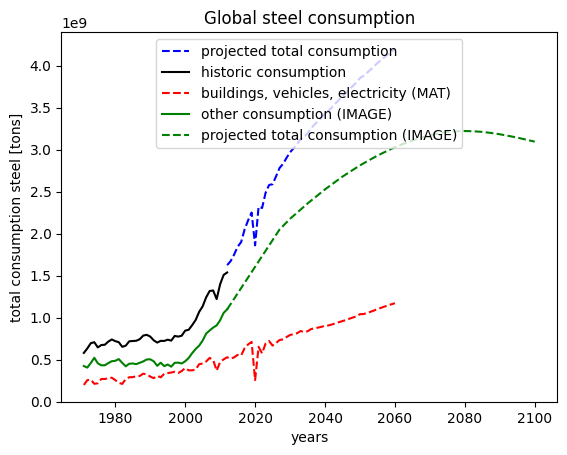

In [23]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(steel.projection_per_region_total.sum(axis = 1) + steel.image_mat_data.sum(axis = 1).loc[2012:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(steel.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(steel.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')
ax.plot(steel.historic_other_fraction_consumption.sum(axis = 1),
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(steel.projection_per_region_total.loc[2012: ].sum(axis = 1),
        linestyle = '--', color = 'green', label = 'projected total consumption (IMAGE)')

ax.set_ylabel("total consumption steel [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global steel consumption")
ax.legend(loc = 'upper center')

In [12]:
region = 'class_ 1'

# 1) Get coefs from projection
coefs_standard = steel.region_model_match.get(region)._coefs
print(coefs_standard)

# 2) Get X to project
# Plot diffferent regions with Gompertz fit
X_axis = np.arange(1, 40001).reshape(-1, 1) # GDP/capita input for Gompertz fit
X_input = np.arange(1, 40001).reshape(-1, 1)/1000  # GDP/capita input for Gompertz fit


# 3) make a of coefs dependent from X --> try: 1% decrease in coefs for 1% increase in X
def adjust_a_gompertz(coefs_standard, X_input):
    """
    Adjust the Gompertz coefficients based on GDP/capita input.
    Only adjust if GDP/cap is higher than 30_000.

    """
    a = coefs_standard[0]
    # now make a dependet from X if X is higher than 30_000, when X lower than 30_000, a is not adjusted
    adjusted_a = np.where(X_input > 25, a * (1 - 0.01 * (X_input - 25)), a)
    return adjusted_a
    

adjusted_a = adjust_a_gompertz(coefs_standard, X_input)

def gompertz_function(X, a, b, c):
    """
    Gompertz function.
    """
    return a * np.exp(-b * np.exp(-c * X))


y_adjusted = gompertz_function(X_input, adjusted_a, coefs_standard[1], coefs_standard[2])
y_standard = gompertz_function(X_input, coefs_standard[0], coefs_standard[1], coefs_standard[2])

# 4) find a way to adapt for all regions in a systematic approach

[3.83978468e-01 3.68985995e+06 2.71240824e+05]


In [13]:
# get coefs from projection for all regions
general_coefs = steel.model_groups.get('all')[6]._coefs

# from a gdp/cap of 20_000, a is adjusted to reach general coefs

def adjust_a_gompertz_all_regions(coefs_standard, X_input):
    """
    Adjust the Gompertz coefficients based on GDP/capita input.
    Only adjust if GDP/cap is higher than 20_000.
    """
    a = coefs_standard[0]
    # now make a dependet from X if X is higher than 20_000, when X lower than 20_000, a is not adjusted
    adjusted_a = np.where(X_input > 20, a * (1 - 0.01 * (X_input - 20)), a)
    return adjusted_a

 

